# CAV – wersja hierarchiczna z HCEP



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import clip
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from data_loading import load_sun_data
import torchvision.models as models
from torchvision import transforms as trn
import torch.nn as nn
from tqdm import tqdm
from dataloaders import create_sun_dataloader
from cav_utils import (
    calculate_hcep_cav,
    calculate_filtered_cav,
    calculate_centroid_cav,
    get_cosine_similarity,
    projection_ratio,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Używane urządzenie: {DEVICE}')



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\zieli\miniconda3\envs\ml2\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\zieli\miniconda3\envs\ml2\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\zieli\miniconda3\envs\ml2\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.start()
  File "c:\Users

AttributeError: _ARRAY_API not found

Używane urządzenie: cuda


## 21. Definicja funkcji CAV

### 1.1 Standardowy MeanDiff (bazowy, do porównania)

In [2]:
# Funkcja calculate_centroid_cav została przeniesiona do cav_utils.py


### 1.2 HCEP – Hierarchical Concept Embedding Projection

In [3]:
# Funkcje calculate_hcep_cav, get_cosine_similarity i projection_ratio zostały przeniesione do cav_utils.py


## 2. Wczytanie danych i ekstrakcja cech

In [4]:
df_sun, attributes_list, attr_cols = load_sun_data(
    base_path='data/SUN/SUNAttributeDB', threshold=0.5
)
print(f'Wczytano obrazy: {len(df_sun)}')
print(f'Liczba atrybutów: {len(attr_cols)}')
df_sun.head(3)

Wczytano obrazy: 14340
Liczba atrybutów: 102


,image_id,file_path,class_id,sailing/ boating,driving,biking,transporting things or people,sunbathing,vacationing/ touring,hiking,...,far-away horizon,no horizon,rugged scene,mostly vertical components,mostly horizontal components,symmetrical,cluttered space,scary,soothing,stressful
0,1,a/abbey/sun_aakbdcgfpksytcwj.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,a/abbey/sun_aaoktempcmudsvna.jpg,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,a/abbey/sun_abegcweqnetpdlrh.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Model ResNet18 
model_file = 'models/resnet18_places365.pth'
conv_model_places = models.resnet18(num_classes=365)
checkpoint = torch.load(model_file, map_location='cpu', weights_only=False)
state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model_places.load_state_dict(state_dict)
conv_model_places.fc = nn.Identity()
conv_model_places = conv_model_places.to(DEVICE).eval()

# CLIP
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)),
    trn.CenterCrop(224),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print('Zaladowano: ResNet18-Places365, CLIP ViT-B/32')

Zaladowano: ResNet18-Places365, CLIP ViT-B/32


In [6]:
dataloader_resnet = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=centre_crop,
    attr_cols=attr_cols, batch_size=32, num_workers=4
)
dataloader_clip = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=clip_preprocess,
    attr_cols=attr_cols, batch_size=64, num_workers=4
)

In [7]:
features_places = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_resnet, desc='ResNet18-Places365 features'):
        feats = conv_model_places(batch_imgs.to(DEVICE))
        features_places.append(feats.cpu().numpy())
X_places = np.concatenate(features_places, axis=0)
print(f'Places365 features: {X_places.shape}')

ResNet18-Places365 features: 100%|██████████| 449/449 [00:30<00:00, 14.73it/s]

Places365 features: (14340, 512)


In [8]:
features_clip = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_clip, desc='CLIP features'):
        feats = clip_model.encode_image(batch_imgs.to(DEVICE)).float()
        feats = feats / feats.norm(dim=1, keepdim=True)
        features_clip.append(feats.cpu().numpy())
X_clip = np.concatenate(features_clip, axis=0)
print(f'CLIP features: {X_clip.shape}')

CLIP features: 100%|██████████| 225/225 [00:32<00:00,  6.94it/s]

CLIP features: (14340, 512)


## 3. Definicja hierarchii pojęć

Używamy tych samych par co w notebooku MeanDiff.  
Klucz: `(child, parent)` - child jest pojęciem podrzędnym wewnątrz parent.

In [9]:
empirical_pairs = [
    ('research',          'enclosed area'),
    ('camping',           'open area'),
    ('medical activity',  'enclosed area'),
    ('gaming',            'enclosed area'),
    ('sand',              'natural light'),
    ('carpet',            'enclosed area'),
]

semantic_pairs = [
    ('ocean',               'open area'),
    ('conducting business', 'working'),
    ('pavement',            'asphalt'),
    ('climbing',            'rock/stone'),
    ('rusty',               'aged/ worn'),
    ('ice',                 'cold'),
]

all_pairs = empirical_pairs + semantic_pairs
child_to_parent = {child: parent for child, parent in all_pairs}

all_concepts = set()
for child, parent in all_pairs:
    all_concepts.add(child)
    all_concepts.add(parent)

print(f'Laczna liczba pojec: {len(all_concepts)}')
print('Pary (dziecko -> rodzic):')
for c, p in all_pairs:
    print(f'  {c} -> {p}')

Laczna liczba pojec: 20
Pary (dziecko -> rodzic):
  research -> enclosed area
  camping -> open area
  medical activity -> enclosed area
  gaming -> enclosed area
  sand -> natural light
  carpet -> enclosed area
  ocean -> open area
  conducting business -> working
  pavement -> asphalt
  climbing -> rock/stone
  rusty -> aged/ worn
  ice -> cold


## 4. Obliczenie HCEP CAV

### Procedura dla każdej pary (dziecko, rodzic):
1. `CAV_parent` metodą MeanDiff
2. `CAV_child_raw` metodą MeanDiff
3. Projekcja HCEP: `CAV_child_hcep = CAV_child_raw - proj(CAV_child_raw -> CAV_parent)`
4. Normalizacja


In [10]:
def compute_hcep_cavs_for_pairs(pairs, df, features, label):
    results = []
    cavs = {}

    for child, parent in pairs:
        idx_child_pos  = df.index[df[child]  == 1.0].tolist()
        idx_child_neg  = df.index[df[child]  == 0.0].tolist()
        idx_parent_pos = df.index[df[parent] == 1.0].tolist()
        idx_parent_neg = df.index[df[parent] == 0.0].tolist()

        cav_parent = calculate_centroid_cav(features, idx_parent_pos, idx_parent_neg)
        cavs[parent] = cav_parent

        cav_child_raw = calculate_centroid_cav(features, idx_child_pos, idx_child_neg)
        cos_before = get_cosine_similarity(cav_child_raw, cav_parent)
        proj_r = projection_ratio(cav_child_raw, cav_parent)

        try:
            cav_child_hcep = calculate_hcep_cav(
                features, idx_child_pos, idx_child_neg, parent_cav=cav_parent
            )
        except ValueError as e:
            print(f'  [UWAGA] {child}: {e}')
            cav_child_hcep = cav_child_raw

        cavs[child + '_hcep'] = cav_child_hcep
        cavs[child + '_raw']  = cav_child_raw

        cos_after = get_cosine_similarity(cav_child_hcep, cav_parent)

        results.append({
            'Model': label,
            'Dziecko': child,
            'Rodzic': parent,
            'n_child': len(idx_child_pos),
            'n_parent': len(idx_parent_pos),
            'cos(child_raw, parent)': round(cos_before, 4),
            'proj_ratio (R2)': round(proj_r, 4),
            'cos(child_hcep, parent)': round(cos_after, 6),
        })

    return pd.DataFrame(results), cavs



In [11]:
print('=== ResNet18 - Places365 ===')
df_hcep_places, cavs_places = compute_hcep_cavs_for_pairs(
    all_pairs, df_sun, X_places, 'ResNet18-Places365'
)

print('\n=== CLIP ViT-B/32 ===')
df_hcep_clip, cavs_clip = compute_hcep_cavs_for_pairs(
    all_pairs, df_sun, X_clip, 'CLIP'
)

df_hcep_all = pd.concat([df_hcep_places,  df_hcep_clip], ignore_index=True)

=== ResNet18 - Places365 ===

=== CLIP ViT-B/32 ===


### 4.1 Wynik projekcji: ile energii dziecka leżało wzdłuż rodzica?

Kolumna `proj_ratio (R2)`: udział wariancji wektora dziecka wzdłuż osi rodzica.   


In [12]:
print('\n-- Wyniki projekcji HCEP (wszystkie modele) --')
print(df_hcep_all.to_string(index=False))


-- Wyniki projekcji HCEP (wszystkie modele) --
             Model             Dziecko        Rodzic  n_child  n_parent  cos(child_raw, parent)  proj_ratio (R2)  cos(child_hcep, parent)
ResNet18-Places365            research enclosed area      207      4947                  0.7293           0.5318                     -0.0
ResNet18-Places365             camping     open area      871      5541                  0.7919           0.6270                      0.0
ResNet18-Places365    medical activity enclosed area      118      4947                  0.6150           0.3782                     -0.0
ResNet18-Places365              gaming enclosed area      108      4947                  0.6190           0.3831                      0.0
ResNet18-Places365                sand natural light      351      6709                  0.6086           0.3704                      0.0
ResNet18-Places365              carpet enclosed area      324      4947                  0.8100           0.6561            

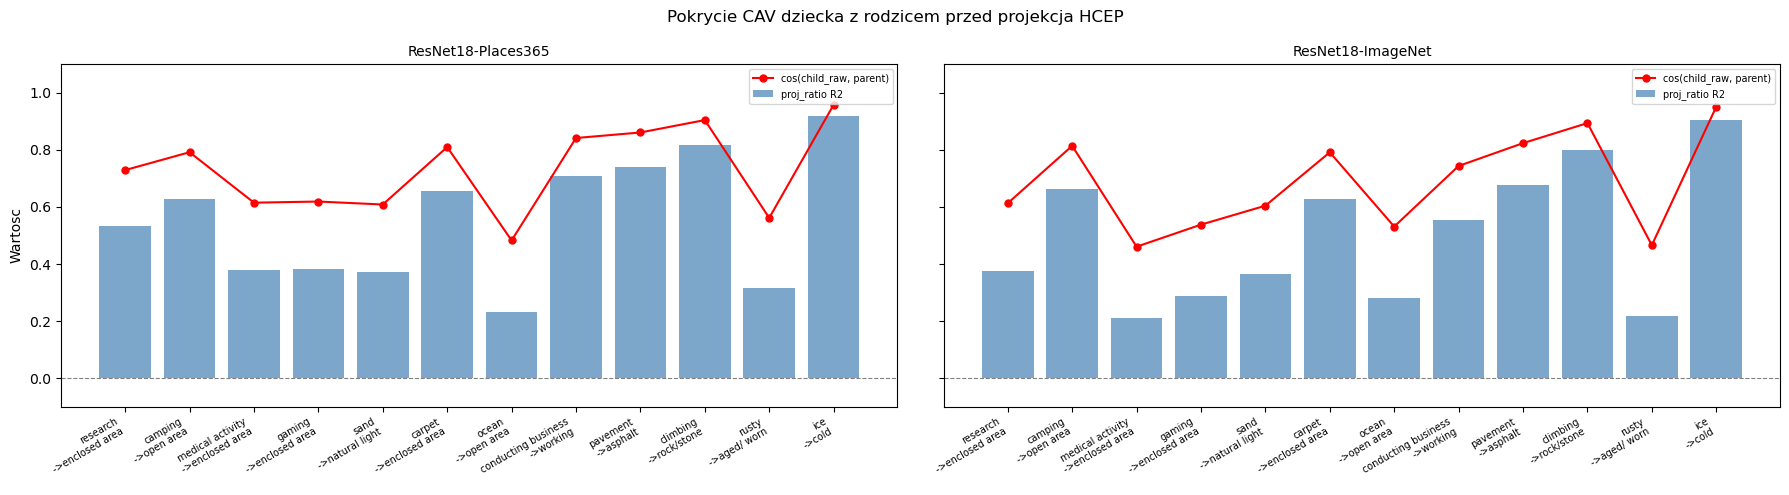

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
model_labels = ['ResNet18-Places365', 'ResNet18-ImageNet', 'CLIP']
dfs = [df_hcep_places,  df_hcep_clip]

for ax, label, df_m in zip(axes, model_labels, dfs):
    pairs_labels = [f"{r['Dziecko']}\n->{r['Rodzic']}" for _, r in df_m.iterrows()]
    proj_vals = df_m['proj_ratio (R2)'].values
    cos_before = df_m['cos(child_raw, parent)'].values

    x = np.arange(len(pairs_labels))
    ax.bar(x, proj_vals, color='steelblue', alpha=0.7, label='proj_ratio R2')
    ax.plot(x, cos_before, 'ro-', label='cos(child_raw, parent)', markersize=5)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(pairs_labels, fontsize=7, rotation=30, ha='right')
    ax.set_title(label, fontsize=10)
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=7)

axes[0].set_ylabel('Wartosc')
fig.suptitle('Pokrycie CAV dziecka z rodzicem przed projekcja HCEP', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Ewaluacja HCEP CAV - AUC na zbiorze testowym

Sprawdzamy jakość HCEP CAV jako klasyfikatora pojęć, porównując go z MeanDiff.

In [14]:
indices = np.arange(len(df_sun))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

print(f'Trening: {len(train_idx)} | Test: {len(test_idx)}')

splits = {
    'ResNet18-Places365': (X_places[train_idx],   X_places[test_idx]),
    'CLIP':               (X_clip[train_idx],     X_clip[test_idx]),
}

df_train_meta = df_sun.iloc[train_idx].reset_index(drop=True)
df_test_meta  = df_sun.iloc[test_idx].reset_index(drop=True)

Trening: 11472 | Test: 2868


In [15]:
def evaluate_cavs(pairs, df_train, df_test, X_train, X_test, model_label):
    records = []

    for child, parent in pairs:
        idx_child_pos_tr  = df_train.index[df_train[child]  == 1.0].tolist()
        idx_child_neg_tr  = df_train.index[df_train[child]  == 0.0].tolist()
        idx_parent_pos_tr = df_train.index[df_train[parent] == 1.0].tolist()
        idx_parent_neg_tr = df_train.index[df_train[parent] == 0.0].tolist()

        cav_parent = calculate_centroid_cav(X_train, idx_parent_pos_tr, idx_parent_neg_tr)
        cav_md     = calculate_centroid_cav(X_train, idx_child_pos_tr, idx_child_neg_tr)

        try:
            cav_hcep = calculate_hcep_cav(
                X_train, idx_child_pos_tr, idx_child_neg_tr, parent_cav=cav_parent
            )
        except ValueError:
            cav_hcep = cav_md

        y_test = df_test[child].values
        scores_md   = cosine_similarity(X_test, cav_md.reshape(1,   -1)).flatten()
        scores_hcep = cosine_similarity(X_test, cav_hcep.reshape(1, -1)).flatten()

        auc_md   = roc_auc_score(y_test, scores_md)
        auc_hcep = roc_auc_score(y_test, scores_hcep)

        hard_mask   = (df_test[parent] == 1.0).values
        y_test_hard = y_test[hard_mask]
        X_test_hard = X_test[hard_mask]

        auc_md_hard = auc_hcep_hard = None

        if len(np.unique(y_test_hard)) > 1:
            s_md_h   = cosine_similarity(X_test_hard, cav_md.reshape(1,   -1)).flatten()
            s_hcep_h = cosine_similarity(X_test_hard, cav_hcep.reshape(1, -1)).flatten()
            auc_md_hard   = roc_auc_score(y_test_hard, s_md_h)
            auc_hcep_hard = roc_auc_score(y_test_hard, s_hcep_h)

        records.append({
            'Model':         model_label,
            'Dziecko':       child,
            'Rodzic':        parent,
            'AUC_MeanDiff':  round(auc_md,   3),
            'AUC_HCEP':      round(auc_hcep, 3),
            'Delta':         round(auc_hcep - auc_md, 3),
            'AUC_MD_Hard':   round(auc_md_hard,   3) if auc_md_hard   else None,
            'AUC_HCEP_Hard': round(auc_hcep_hard, 3) if auc_hcep_hard else None,
            'Delta_Hard':    round((auc_hcep_hard or 0) - (auc_md_hard or 0), 3)
                             if (auc_hcep_hard and auc_md_hard) else None,
        })

    return pd.DataFrame(records)

print('Funkcja evaluate_cavs gotowa.')

Funkcja evaluate_cavs gotowa.


In [16]:
eval_dfs = {}
for model_label, (X_tr, X_te) in splits.items():
    print(f'\n{"="*60}')
    print(f'  Ewaluacja: {model_label}')
    print(f'{"="*60}')
    df_eval = evaluate_cavs(
        all_pairs, df_train_meta, df_test_meta, X_tr, X_te, model_label
    )
    eval_dfs[model_label] = df_eval
    print(df_eval[['Dziecko', 'Rodzic', 'AUC_MeanDiff', 'AUC_HCEP',
                   'Delta', 'AUC_MD_Hard', 'AUC_HCEP_Hard', 'Delta_Hard'
                  ]].to_string(index=False))


  Ewaluacja: ResNet18-Places365
            Dziecko        Rodzic  AUC_MeanDiff  AUC_HCEP  Delta  AUC_MD_Hard  AUC_HCEP_Hard  Delta_Hard
           research enclosed area         0.958     0.922 -0.036        0.888          0.896       0.008
            camping     open area         0.959     0.916 -0.044        0.911          0.903      -0.008
   medical activity enclosed area         0.980     0.960 -0.021        0.946          0.948       0.002
             gaming enclosed area         0.965     0.948 -0.017        0.947          0.945      -0.002
               sand natural light         0.955     0.953 -0.002        0.916          0.934       0.017
             carpet enclosed area         0.914     0.789 -0.125        0.770          0.769      -0.001
              ocean     open area         0.982     0.981 -0.001        0.967          0.971       0.004
conducting business       working         0.893     0.802 -0.091        0.646          0.693       0.047
           pavement   



### 5.1 Podsumowanie zbiorcze

In [17]:
df_combined = pd.concat(eval_dfs.values(), ignore_index=True)

df_agg = df_combined.groupby(['Dziecko', 'Rodzic']).agg(
    AUC_MD_mean   = ('AUC_MeanDiff', 'mean'),
    AUC_HCEP_mean = ('AUC_HCEP',     'mean'),
    Delta_mean    = ('Delta',         'mean'),
).round(3).reset_index()

df_agg['Ocena HCEP'] = df_agg['Delta_mean'].apply(
    lambda d: 'HCEP lepszy' if d > 0.01
              else ('Porownywalny' if abs(d) <= 0.01 else 'HCEP gorszy')
)

print('\n-- Srednie AUC po modelach --')
print(df_agg.to_string(index=False))


-- Srednie AUC po modelach --
            Dziecko        Rodzic  AUC_MD_mean  AUC_HCEP_mean  Delta_mean   Ocena HCEP
            camping     open area        0.952          0.893      -0.060  HCEP gorszy
             carpet enclosed area        0.908          0.787      -0.121  HCEP gorszy
           climbing    rock/stone        0.912          0.770      -0.141  HCEP gorszy
conducting business       working        0.906          0.815      -0.090  HCEP gorszy
             gaming enclosed area        0.970          0.956      -0.014  HCEP gorszy
                ice          cold        0.983          0.764      -0.219  HCEP gorszy
   medical activity enclosed area        0.985          0.970      -0.016  HCEP gorszy
              ocean     open area        0.980          0.972      -0.008 Porownywalny
           pavement       asphalt        0.891          0.732      -0.158  HCEP gorszy
           research enclosed area        0.962          0.925      -0.037  HCEP gorszy
            

### 5.2 Wizualizacja: MeanDiff vs HCEP

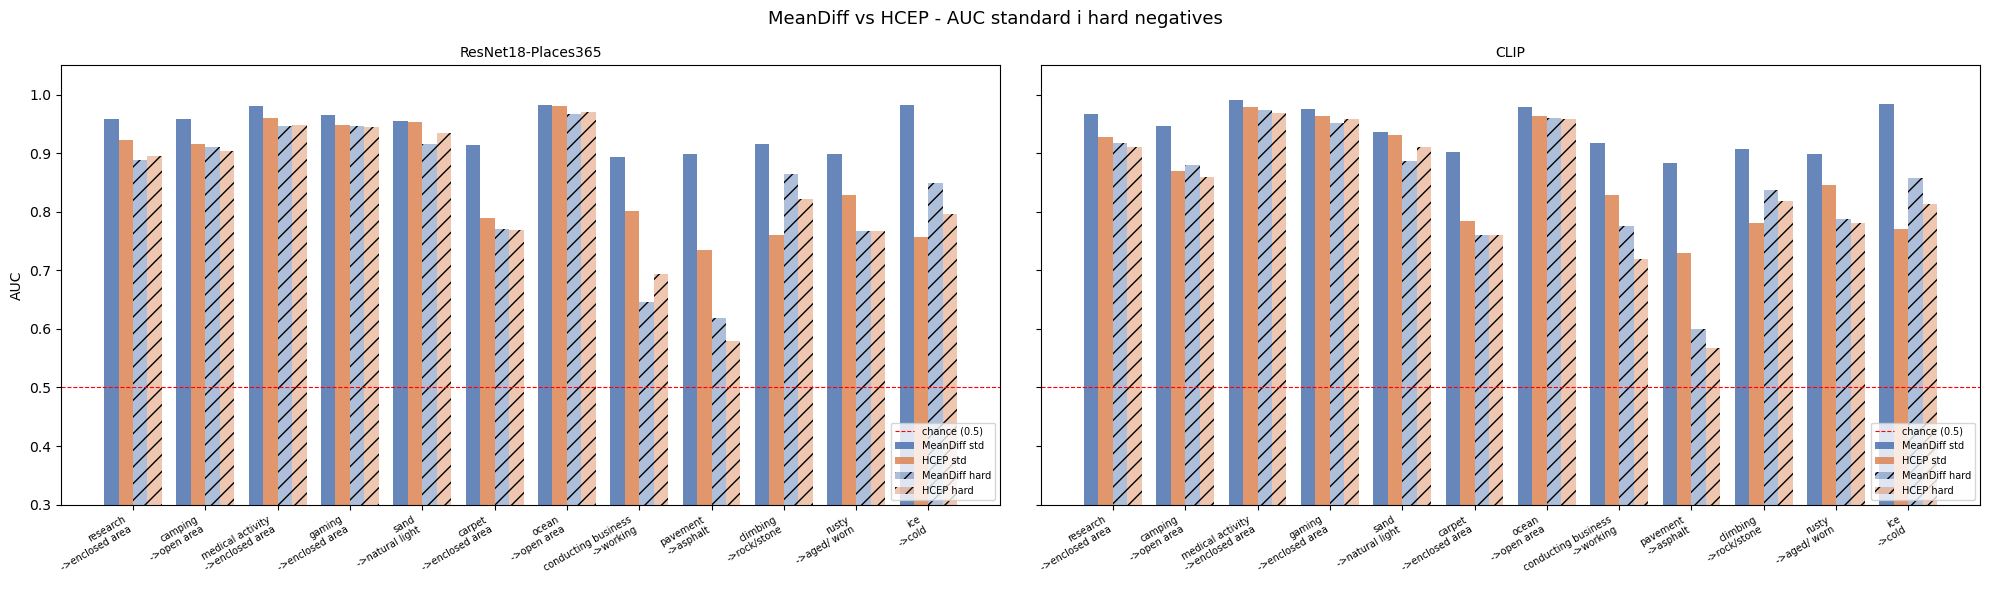

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

for ax, (model_label, df_m) in zip(axes, eval_dfs.items()):
    pair_labels = [f"{r['Dziecko']}\n->{r['Rodzic']}" for _, r in df_m.iterrows()]
    x = np.arange(len(pair_labels))
    w = 0.2

    ax.bar(x - 1.5*w, df_m['AUC_MeanDiff'],            w, label='MeanDiff std',  color='#4C72B0', alpha=0.85)
    ax.bar(x - 0.5*w, df_m['AUC_HCEP'],               w, label='HCEP std',       color='#DD8452', alpha=0.85)
    ax.bar(x + 0.5*w, df_m['AUC_MD_Hard'].fillna(0),   w, label='MeanDiff hard', color='#4C72B0', alpha=0.45, hatch='//')
    ax.bar(x + 1.5*w, df_m['AUC_HCEP_Hard'].fillna(0), w, label='HCEP hard',     color='#DD8452', alpha=0.45, hatch='//')

    ax.axhline(0.5, color='red', lw=0.8, ls='--', label='chance (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, fontsize=7, rotation=30, ha='right')
    ax.set_title(model_label, fontsize=10)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=7, loc='lower right')

axes[0].set_ylabel('AUC')
fig.suptitle('MeanDiff vs HCEP - AUC standard i hard negatives', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Podział na pary semantyczne vs empiryczne


-- Srednie AUC według typu hierarchii --
             AUC_MeanDiff  AUC_HCEP  Delta
Typ                                       
Empiryczna          0.954     0.912 -0.042
Semantyczna         0.928     0.815 -0.113


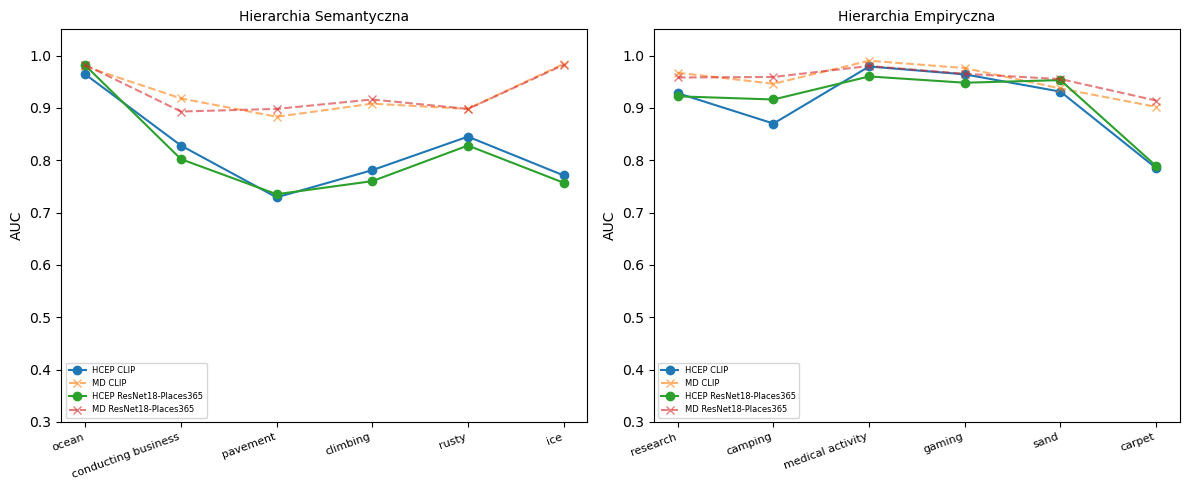

In [19]:
semantic_children  = {c for c, _ in semantic_pairs}
empirical_children = {c for c, _ in empirical_pairs}

df_combined['Typ'] = df_combined['Dziecko'].apply(
    lambda c: 'Semantyczna' if c in semantic_children else 'Empiryczna'
)

summary_by_type = df_combined.groupby('Typ')[['AUC_MeanDiff', 'AUC_HCEP', 'Delta']].mean().round(3)
print('\n-- Srednie AUC według typu hierarchii --')
print(summary_by_type)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, typ in zip(axes, ['Semantyczna', 'Empiryczna']):
    sub = df_combined[df_combined['Typ'] == typ]
    children = sub['Dziecko'].unique()
    x = np.arange(len(children))
    for model_label, grp in sub.groupby('Model'):
        ax.plot(x, grp['AUC_HCEP'].values,     marker='o', label=f'HCEP {model_label}')
        ax.plot(x, grp['AUC_MeanDiff'].values,  marker='x', ls='--', label=f'MD {model_label}', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(children, rotation=20, ha='right', fontsize=8)
    ax.set_title(f'Hierarchia {typ}', fontsize=10)
    ax.set_ylim(0.3, 1.05)
    ax.set_ylabel('AUC')
    ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

## 6. HCEP based on filtering

Alternatywne podejście do hierarchicznej detekcji pojęć – oparte na **filtrowaniu**.

### Idea

**Trening:**
- Oblicz wektory `SV_A` i `SV_B` metodą MeanDiff (jak w artykule).
- Wektor filtrujący: `SV_A - SV_B`  
  Z definicji `(SV_A - SV_B)` jest ortogonalny do `SV_B`  
  _(gdy `SV_B = proj(SV_A → SV_B)`, co zachodzi przy znormalizowanych wektorach klasy)_

**Inferencja (detekcja A):**
1. Sprawdź, czy B istnieje (wynik cosinusowy `score_B > 0`).
2. Jeśli **B nie istnieje** → A też nie istnieje (zwróć wynik `-1`).
3. Jeśli **B istnieje** → oceń A używając `SV_A - SV_B` zamiast `SV_A`.


### 6.1 Trening – obliczenie wektorów filtrujących

In [20]:
def calculate_filtering_cav(sv_a: np.ndarray, sv_b: np.ndarray) -> np.ndarray:
    """
    Wektor filtrujący: SV_A - SV_B (znormalizowany).
    Ortogonalny do SV_B gdy SV_B = proj(SV_A -> SV_B).
    """
    sv_diff = sv_a - sv_b
    norm = np.linalg.norm(sv_diff)
    if norm < 1e-10:
        raise ValueError("SV_A - SV_B jest wektorem zerowym – pojęcia identyczne?")
    return sv_diff / norm


def compute_filtering_cavs_for_pairs(pairs, df, features, label):
    """
    Oblicza dla każdej pary (A, B):
      - SV_A, SV_B  (MeanDiff)
      - SV_filter = (SV_A - SV_B) / ||SV_A - SV_B||
      - cos(SV_filter, SV_B)  – weryfikacja ortogonalności
    """
    results = []
    cavs = {}

    for child, parent in pairs:
        idx_child_pos  = df.index[df[child]  == 1.0].tolist()
        idx_child_neg  = df.index[df[child]  == 0.0].tolist()
        idx_parent_pos = df.index[df[parent] == 1.0].tolist()
        idx_parent_neg = df.index[df[parent] == 0.0].tolist()

        sv_b = calculate_centroid_cav(features, idx_parent_pos, idx_parent_neg)
        sv_a = calculate_centroid_cav(features, idx_child_pos,  idx_child_neg)

        try:
            sv_filter = calculate_filtering_cav(sv_a, sv_b)
        except ValueError as e:
            print(f"  [UWAGA] {child}: {e}")
            sv_filter = sv_a

        # kosinus między wektorem filtrującym a rodzicem (im bliżej 0, tym lepiej)
        cos_filter_b = float(np.dot(sv_filter, sv_b) /
                             (np.linalg.norm(sv_filter) * np.linalg.norm(sv_b) + 1e-12))

        # porównanie z HCEP (cos po projekcji)
        cos_hcep_b = get_cosine_similarity(
            calculate_hcep_cav(features, idx_child_pos, idx_child_neg, sv_b),
            sv_b
        )

        cavs[f"{child}_sv_b"]     = sv_b
        cavs[f"{child}_sv_a"]     = sv_a
        cavs[f"{child}_filter"]   = sv_filter

        results.append({
            "Model":            label,
            "Dziecko":          child,
            "Rodzic":           parent,
            "cos(filter, B)":   round(cos_filter_b, 6),
            "cos(HCEP, B)":     round(cos_hcep_b,   6),
            "||SV_A - SV_B||":  round(float(np.linalg.norm(sv_a - sv_b)), 4),
        })

    return pd.DataFrame(results), cavs


print("Funkcja compute_filtering_cavs_for_pairs gotowa.")


Funkcja compute_filtering_cavs_for_pairs gotowa.


In [21]:
print("=== ResNet18-Places365 ===")
df_filter_places, cavs_filter_places = compute_filtering_cavs_for_pairs(
    all_pairs, df_sun, X_places, "ResNet18-Places365"
)

print("\n=== CLIP ViT-B/32 ===")
df_filter_clip, cavs_filter_clip = compute_filtering_cavs_for_pairs(
    all_pairs, df_sun, X_clip, "CLIP"
)

df_filter_all = pd.concat([df_filter_places, df_filter_clip], ignore_index=True)
print("\n-- Ortogonalność wektora filtrującego vs. HCEP --")
print(df_filter_all.to_string(index=False))


=== ResNet18-Places365 ===

=== CLIP ViT-B/32 ===

-- Ortogonalność wektora filtrującego vs. HCEP --
             Model             Dziecko        Rodzic  cos(filter, B)  cos(HCEP, B)  ||SV_A - SV_B||
ResNet18-Places365            research enclosed area       -0.367930          -0.0           0.7359
ResNet18-Places365             camping     open area       -0.322601           0.0           0.6452
ResNet18-Places365    medical activity enclosed area       -0.438739          -0.0           0.8775
ResNet18-Places365              gaming enclosed area       -0.436482           0.0           0.8730
ResNet18-Places365                sand natural light       -0.442389           0.0           0.8848
ResNet18-Places365              carpet enclosed area       -0.308200           0.0           0.6164
ResNet18-Places365               ocean     open area       -0.508611          -0.0           1.0172
ResNet18-Places365 conducting business       working       -0.281292          -0.0           0.5626

### 6.2 Inferencja z filtrowaniem

Dwuetapowa detekcja:
1. **Gate B**: jeśli `score_B ≤ threshold_b` → `score_final = -1` (A niemożliwe bez B).
2. **Score A|B**: `cosine_similarity(x, SV_A - SV_B)`.

Dla AUC łączymy: próbki bez B dostają wynik `-1` (poniżej każdej wartości progowej).


In [22]:
def filtering_inference_scores(
    X: np.ndarray,
    sv_a: np.ndarray,
    sv_b: np.ndarray,
    threshold_b: float = 0.0,
) -> np.ndarray:
    """
    Zwraca wyniki filtrujące dla całego zbioru X.
    - score_B > threshold_b  →  score = cosine(X, SV_A - SV_B)
    - score_B ≤ threshold_b  →  score = -1  (B nieobecne, A niemożliwe)
    """
    sv_filter = calculate_filtering_cav(sv_a, sv_b)

    scores_b = cosine_similarity(X, sv_b.reshape(1, -1)).flatten()
    scores_a_given_b = cosine_similarity(X, sv_filter.reshape(1, -1)).flatten()

    b_present = scores_b > threshold_b
    combined  = np.where(b_present, scores_a_given_b, -1.0)
    return combined, scores_b, scores_a_given_b


print("Funkcja filtering_inference_scores gotowa.")


Funkcja filtering_inference_scores gotowa.


### 6.3 Ewaluacja – AUC: MeanDiff vs HCEP vs Filtering

In [23]:
def evaluate_filtering(pairs, df_train, df_test, X_train, X_test,
                        model_label, threshold_b=0.0):
    """
    Porównanie MeanDiff / HCEP / Filtering (pełny zbiór + hard: tylko próbki z B).
    """
    records = []

    for child, parent in pairs:
        idx_cp_tr = df_train.index[df_train[child]  == 1.0].tolist()
        idx_cn_tr = df_train.index[df_train[child]  == 0.0].tolist()
        idx_pp_tr = df_train.index[df_train[parent] == 1.0].tolist()
        idx_pn_tr = df_train.index[df_train[parent] == 0.0].tolist()

        sv_b = calculate_centroid_cav(X_train, idx_pp_tr, idx_pn_tr)
        sv_a = calculate_centroid_cav(X_train, idx_cp_tr, idx_cn_tr)
        try:
            cav_hcep = calculate_hcep_cav(X_train, idx_cp_tr, idx_cn_tr,
                                           parent_cav=sv_b)
        except ValueError:
            cav_hcep = sv_a

        y_test = df_test[child].values

        # --- pełna ewaluacja ------------------------------------------------
        scores_md   = cosine_similarity(X_test, sv_a.reshape(1, -1)).flatten()
        scores_hcep = cosine_similarity(X_test, cav_hcep.reshape(1, -1)).flatten()
        try:
            scores_filt, _, _ = filtering_inference_scores(
                X_test, sv_a, sv_b, threshold_b=threshold_b
            )
        except ValueError:
            scores_filt = scores_md

        auc_md   = roc_auc_score(y_test, scores_md)
        auc_hcep = roc_auc_score(y_test, scores_hcep)
        auc_filt = roc_auc_score(y_test, scores_filt)

        # --- hard (tylko próbki z B obecnym) --------------------------------
        hard_mask   = (df_test[parent] == 1.0).values
        y_hard      = y_test[hard_mask]
        X_hard      = X_test[hard_mask]

        auc_md_h = auc_hcep_h = auc_filt_h = None
        if len(np.unique(y_hard)) > 1:
            auc_md_h   = roc_auc_score(y_hard,
                             cosine_similarity(X_hard, sv_a.reshape(1,-1)).flatten())
            auc_hcep_h = roc_auc_score(y_hard,
                             cosine_similarity(X_hard, cav_hcep.reshape(1,-1)).flatten())
            # W hard: B zawsze obecne → filtering = score A|B (cosine z SV_A-SV_B)
            sv_filter   = calculate_filtering_cav(sv_a, sv_b)
            auc_filt_h  = roc_auc_score(y_hard,
                             cosine_similarity(X_hard, sv_filter.reshape(1,-1)).flatten())

        def r(v): return round(v, 3) if v is not None else None

        records.append({
            "Model":          model_label,
            "Dziecko":        child,
            "Rodzic":         parent,
            "AUC_MeanDiff":   r(auc_md),
            "AUC_HCEP":       r(auc_hcep),
            "AUC_Filtering":  r(auc_filt),
            "Δ(Filt-MD)":     r(auc_filt - auc_md),
            "Δ(Filt-HCEP)":   r(auc_filt - auc_hcep),
            "AUC_MD_Hard":    r(auc_md_h),
            "AUC_HCEP_Hard":  r(auc_hcep_h),
            "AUC_Filt_Hard":  r(auc_filt_h),
            "Δ_Hard(Filt-MD)":   r((auc_filt_h or 0) - (auc_md_h or 0))
                                  if auc_md_h else None,
        })

    return pd.DataFrame(records)


print("Funkcja evaluate_filtering gotowa.")


Funkcja evaluate_filtering gotowa.


In [24]:
filt_eval_dfs = {}
for model_label, (X_tr, X_te) in splits.items():
    print(f"\n{'='*60}")
    print(f"  Ewaluacja Filtering: {model_label}")
    print(f"{'='*60}")
    df_filt = evaluate_filtering(
        all_pairs, df_train_meta, df_test_meta, X_tr, X_te, model_label
    )
    filt_eval_dfs[model_label] = df_filt
    cols = ["Dziecko", "Rodzic",
            "AUC_MeanDiff", "AUC_HCEP", "AUC_Filtering",
            "Δ(Filt-MD)", "Δ(Filt-HCEP)"]
    print(df_filt[cols].to_string(index=False))



  Ewaluacja Filtering: ResNet18-Places365
            Dziecko        Rodzic  AUC_MeanDiff  AUC_HCEP  AUC_Filtering  Δ(Filt-MD)  Δ(Filt-HCEP)
           research enclosed area         0.958     0.922          0.941      -0.017         0.019
            camping     open area         0.959     0.916          0.949      -0.011         0.033
   medical activity enclosed area         0.980     0.960          0.968      -0.012         0.008
             gaming enclosed area         0.965     0.948          0.956      -0.009         0.008
               sand natural light         0.955     0.953          0.898      -0.057        -0.055
             carpet enclosed area         0.914     0.789          0.877      -0.037         0.088
              ocean     open area         0.982     0.981          0.868      -0.115        -0.113
conducting business       working         0.893     0.802          0.780      -0.113        -0.022
           pavement       asphalt         0.898     0.735         

### 6.4 Podsumowanie zbiorcze: MeanDiff vs HCEP vs Filtering

In [25]:
df_filt_combined = pd.concat(filt_eval_dfs.values(), ignore_index=True)

df_filt_agg = df_filt_combined.groupby(["Dziecko", "Rodzic"]).agg(
    AUC_MD_mean    = ("AUC_MeanDiff",  "mean"),
    AUC_HCEP_mean  = ("AUC_HCEP",      "mean"),
    AUC_Filt_mean  = ("AUC_Filtering", "mean"),
    Δ_Filt_MD_mean = ("Δ(Filt-MD)",   "mean"),
    Δ_Filt_HC_mean = ("Δ(Filt-HCEP)", "mean"),
).round(3).reset_index()

def rank(row):
    scores = {"MeanDiff": row.AUC_MD_mean,
              "HCEP":     row.AUC_HCEP_mean,
              "Filtering":row.AUC_Filt_mean}
    return max(scores, key=scores.get)

df_filt_agg["Najlepszy"] = df_filt_agg.apply(rank, axis=1)
print("\n-- Średnie AUC po modelach (MeanDiff / HCEP / Filtering) --")
print(df_filt_agg.to_string(index=False))



-- Średnie AUC po modelach (MeanDiff / HCEP / Filtering) --
            Dziecko        Rodzic  AUC_MD_mean  AUC_HCEP_mean  AUC_Filt_mean  Δ_Filt_MD_mean  Δ_Filt_HC_mean Najlepszy
            camping     open area        0.952          0.893          0.931          -0.022           0.038  MeanDiff
             carpet enclosed area        0.908          0.787          0.870          -0.038           0.083  MeanDiff
           climbing    rock/stone        0.912          0.770          0.829          -0.082           0.059  MeanDiff
conducting business       working        0.906          0.815          0.811          -0.094          -0.004  MeanDiff
             gaming enclosed area        0.970          0.956          0.958          -0.013           0.001  MeanDiff
                ice          cold        0.983          0.764          0.911          -0.072           0.147  MeanDiff
   medical activity enclosed area        0.985          0.970          0.972          -0.013           0.0

### 6.5 Wizualizacja: MeanDiff vs HCEP vs Filtering

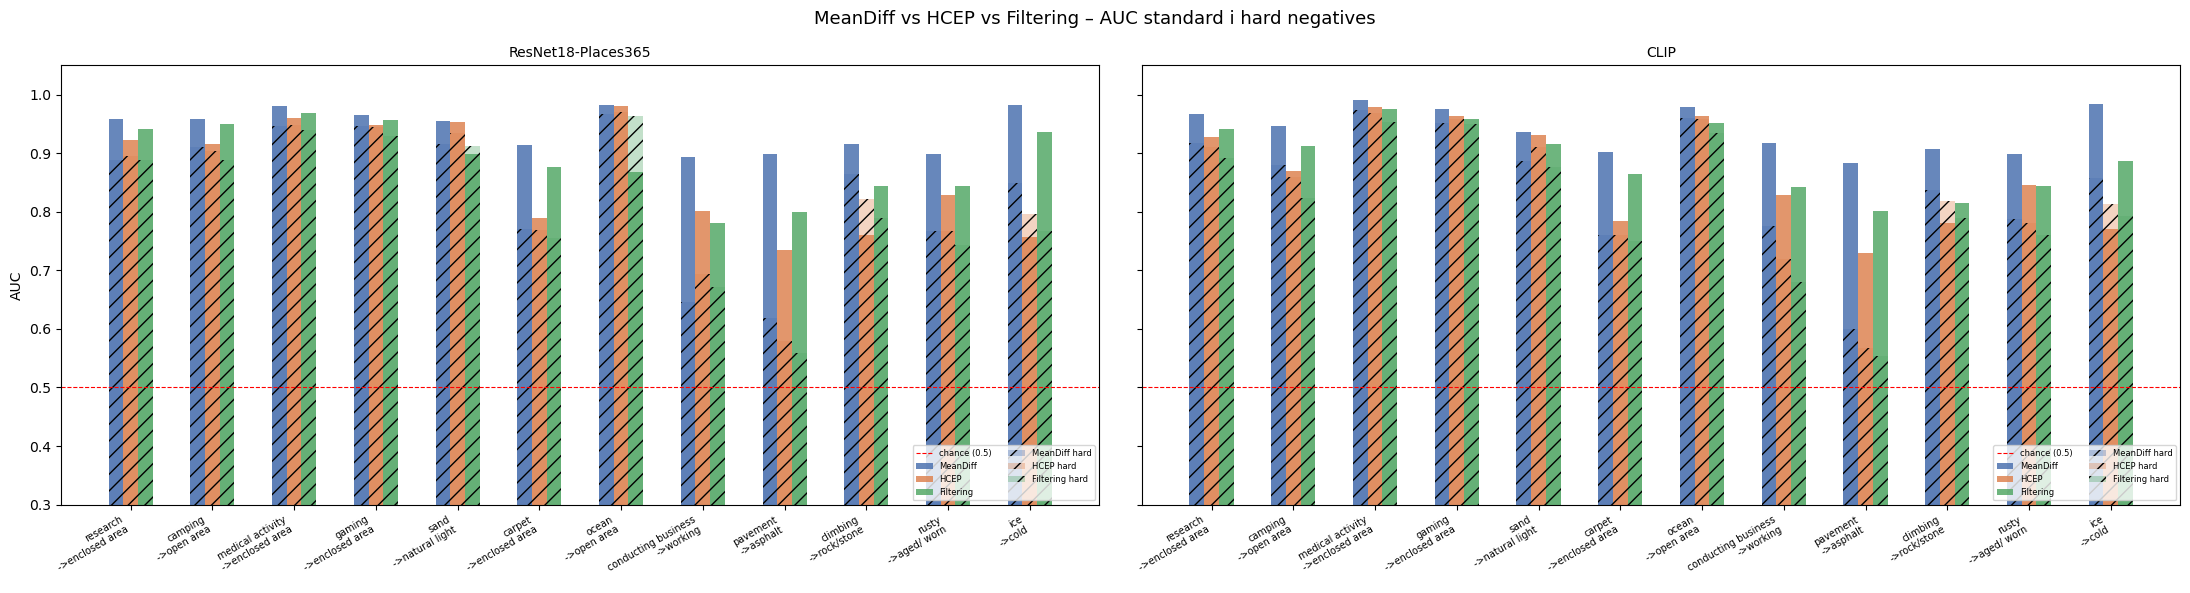

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)

for ax, (model_label, df_m) in zip(axes, filt_eval_dfs.items()):
    pair_labels = [f"{r['Dziecko']}\n->{r['Rodzic']}" for _, r in df_m.iterrows()]
    x = np.arange(len(pair_labels))
    w = 0.18

    ax.bar(x - w,   df_m["AUC_MeanDiff"],            w, label="MeanDiff",  color="#4C72B0", alpha=0.85)
    ax.bar(x,       df_m["AUC_HCEP"],                w, label="HCEP",      color="#DD8452", alpha=0.85)
    ax.bar(x + w,   df_m["AUC_Filtering"],            w, label="Filtering", color="#55A868", alpha=0.85)

    # hard negatives (kreskowanie)
    ax.bar(x - w,   df_m["AUC_MD_Hard"].fillna(0),   w, color="#4C72B0", alpha=0.35, hatch="//", label="MeanDiff hard")
    ax.bar(x,       df_m["AUC_HCEP_Hard"].fillna(0), w, color="#DD8452", alpha=0.35, hatch="//", label="HCEP hard")
    ax.bar(x + w,   df_m["AUC_Filt_Hard"].fillna(0), w, color="#55A868", alpha=0.35, hatch="//", label="Filtering hard")

    ax.axhline(0.5, color="red", lw=0.8, ls="--", label="chance (0.5)")
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, fontsize=7, rotation=30, ha="right")
    ax.set_title(model_label, fontsize=10)
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=6, loc="lower right", ncol=2)

axes[0].set_ylabel("AUC")
fig.suptitle("MeanDiff vs HCEP vs Filtering – AUC standard i hard negatives", fontsize=13)
plt.tight_layout()
plt.show()


### 6.6 Weryfikacja ortogonalności `SV_A - SV_B` ⊥ `SV_B`

Z definicji, gdy `SV_B = proj(SV_A → SV_B)`, różnica `SV_A - SV_B` jest ortogonalna do `SV_B`.  
Sprawdzamy empirycznie, jak blisko zera jest `cos(SV_A - SV_B, SV_B)` w porównaniu do `cos(HCEP, SV_B)`.


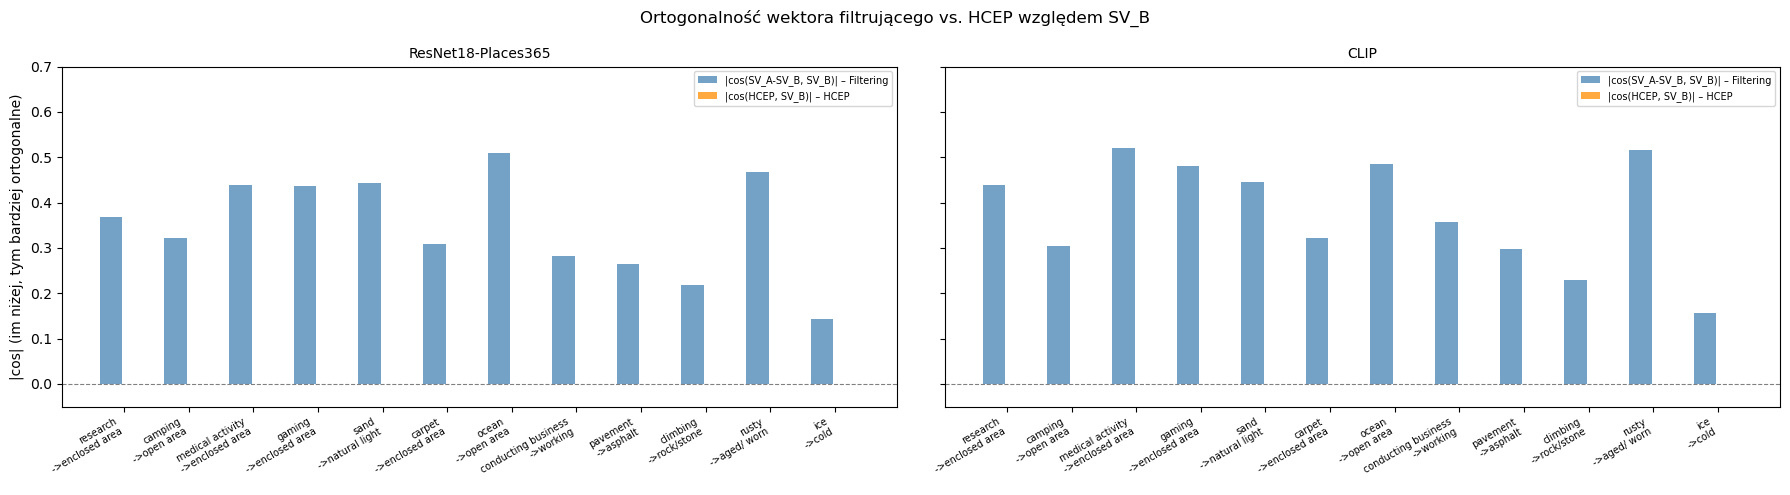

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, df_m in zip(axes, [df_filter_places, df_filter_clip]):
    model_label = df_m["Model"].iloc[0]
    pair_labels = [f"{r['Dziecko']}\n->{r['Rodzic']}" for _, r in df_m.iterrows()]
    x = np.arange(len(pair_labels))

    ax.bar(x - 0.2, df_m["cos(filter, B)"].abs(), 0.35,
           color="steelblue", alpha=0.75, label="|cos(SV_A-SV_B, SV_B)| – Filtering")
    ax.bar(x + 0.2, df_m["cos(HCEP, B)"].abs(),   0.35,
           color="darkorange", alpha=0.75, label="|cos(HCEP, SV_B)| – HCEP")

    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.set_xticks(x)
    ax.set_xticklabels(pair_labels, fontsize=7, rotation=30, ha="right")
    ax.set_title(model_label, fontsize=10)
    ax.set_ylim(-0.05, 0.7)
    ax.legend(fontsize=7)

axes[0].set_ylabel("|cos| (im niżej, tym bardziej ortogonalne)")
fig.suptitle("Ortogonalność wektora filtrującego vs. HCEP względem SV_B", fontsize=12)
plt.tight_layout()
plt.show()
